# Perturbation Explorer

Visualises how each kinematic perturbation parameter shifts the focal spot across different sun positions.

**Workflow**
1. **Config** — pick a heliostat, set per-parameter-group deltas, choose number of sun positions.
2. **Load scenario** — loads the single-heliostat scenario (deflectometry surface, latest ARTIST).
3. **Load sun positions** — reads PAINT test samples; forward passes run on all, display selects `N_SUN_POSITIONS` evenly spread by elevation.
4. **Forward passes** — clean + one isolated pass per non-zero parameter group + combined (if >1 active).
5. **Grid** — rows = clean reference / isolated groups / combined; columns = sun positions.  
   Text overlay on each perturbed image shows the centroid shift in mrad.
6. **Scatter** — centroid shift vs. sun elevation per group.

In [1]:
import json, sys, pathlib, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
import h5py
warnings.filterwarnings("ignore")

_nb   = pathlib.Path(globals().get("__vsc_ipynb_file__", pathlib.Path().resolve() / "x")).parent  # notebook dir
_src  = _nb.parent                 # .../src
_base = _src.parent                # .../master-thesis
sys.path.insert(0, str(_src))

from artist.raytracing.heliostat_ray_tracer import HeliostatRayTracer
from artist.io.paint_calibration_parser import PaintCalibrationDataParser
from artist.scenario.scenario import Scenario
from artist.util import get_device, set_logger_config
from artist.geometry import bitmap_coordinates_to_target_coordinates
from artist.flux import get_center_of_mass
import paint.util.paint_mappings as paint_mappings

from utils.synth_data import _forward_pass, apply_perturbations, reset_perturbations, _equalize_mapping
from utils.evaluation import build_heliostat_data_mapping

set_logger_config()
import logging; logging.getLogger().setLevel(logging.WARNING)
print("Imports OK")

Imports OK


In [2]:
# ============================================================
#  CONFIG — edit this cell, then re-run all cells below
# ============================================================

# Select one heliostat (ordered by increasing distance from the target)
HELIOSTAT_ID = "AC36"   # options: AC36  AG33  AO34  AW36  BE35

# Kinematic perturbation deltas added to the clean (unperturbed) parameters.
# Set all values to 0.0 for the unperturbed reference.
PERTURBATION_DELTAS = {
    # 4 joint-rotation deviations (rad)
    # [0] first_joint_tilt_n  [1] first_joint_tilt_u
    # [2] second_joint_tilt_e [3] second_joint_tilt_n
    "rotation_rad":       [0.05, 0.0, 0.0, 0.0],

    # 2 actuator initial-angle deviations a_i (rad)
    "actuator_angle_rad": [0.0, 0.0],

    # 2 actuator stroke-length deviations b_i (m)
    "actuator_stroke_m":  [0.0, 0.0],

    # 2 actuator offset deviations c_i (m)
    "actuator_offset_m":  [0.0, 0.0],

    # 9 joint + concentrator translation deviations (m)
    # [0-2] first_joint E/N/U  [3-5] second_joint E/N/U  [6-8] concentrator E/N/U
    "translation_m":      [0.0] * 9,

    # 3 heliostat base-position offset in ENU (m)
    "base_position_m":    [0.0, 0.0, 0.0],
}

N_RAYS                 = 100   # rays per light source (higher = cleaner, slower)
SURFACE_POINTS_PER_FACET = 5   # per facet (5×5 = 25 pts); increase for more surface detail
N_SUN_POSITIONS        = 5     # number of sun positions (columns) to display in the grid


In [3]:
%%time
# ── Load single-heliostat scenario ───────────────────────────────────────

SCENARIO_PATH = _base / "scenarios" / "one_heliostat_scenarios" / HELIOSTAT_ID / "scenario.h5"

device = get_device()
print(f"Device   : {device}")
print(f"Scenario : {SCENARIO_PATH}")

with h5py.File(SCENARIO_PATH, "r") as f:
    scenario = Scenario.load_scenario_from_hdf5(
        scenario_file=f,
        device=device,
        number_of_surface_points_per_facet=torch.tensor(
            [SURFACE_POINTS_PER_FACET, SURFACE_POINTS_PER_FACET]
        ),
    )

heliostat_group = scenario.heliostat_field.heliostat_groups[0]
heliostat_names = list(heliostat_group.names)
heliostat_idx   = 0   # always 0 for a single-heliostat scenario

hel_pos       = heliostat_group.positions[heliostat_idx, :3]
target_center = scenario.solar_tower.target_areas[0].centers[:, :3].mean(dim=0)
hel_dist_m    = torch.norm(hel_pos - target_center).item()

print(f"Heliostat: {HELIOSTAT_ID}  (index {heliostat_idx})")
print(f"Distance : {hel_dist_m:.1f} m  (heliostat → target center)")

[2026-05-27 16:26:56,675][artist.util.env][INFO] - No device type provided. The device will default to GPU based on availability and OS, otherwise to CPU.
[2026-05-27 16:26:56,676][artist.util.env][WARNING] - Setting device to CPU. ARTIST only supports CPU for MacOS.
Device   : cpu
Scenario : /Users/alexandru/Master Thesis/master-thesis/scenarios/one_heliostat_scenarios/AC36/scenario.h5
[2026-05-27 16:26:56,677][artist.scenario.scenario][INFO] - Loading an ARTIST scenario HDF5 file. This scenario file is version 1.0.
[2026-05-27 16:26:56,677][artist.field.tower_target_areas_planar][INFO] - Loading the planar tower target areas from an HDF5 file.
[2026-05-27 16:26:56,679][artist.field.tower_target_areas_cylindrical][INFO] - Loading the cylindrical tower target areas from an HDF5 file.
[2026-05-27 16:26:56,680][artist.scene.light_source_array][INFO] - Loading a light source array from an HDF5 file.
[2026-05-27 16:26:56,680][artist.scene.sun][INFO] - Loading sun_1 from an HDF5 file.
[2026

In [4]:
%%time
# ── Load test sun positions ───────────────────────────────────────────────

BENCHMARK_NAME = "benchmark_split-balanced_train-100_validation-50_deflectometry"
PAINT_DIR      = _base / "datasets" / "paint"
BENCHMARK_CSV  = PAINT_DIR / "splits" / f"{BENCHMARK_NAME}.csv"
CAL_DIR        = PAINT_DIR / BENCHMARK_NAME / "calibration_properties"
FLUX_DIR       = PAINT_DIR / BENCHMARK_NAME / "flux_image"

full_mapping = build_heliostat_data_mapping(
    benchmark_csv=BENCHMARK_CSV,
    calibration_properties_dir=CAL_DIR,
    flux_image_dir=FLUX_DIR,
    split="test",
)

heli_mapping = [(hid, cal, flux) for hid, cal, flux in full_mapping if hid == HELIOSTAT_ID]
if not heli_mapping:
    raise RuntimeError(f"{HELIOSTAT_ID} not found in test split")

n_samples = len(heli_mapping[0][1])
equalized  = _equalize_mapping(heli_mapping, sample_limit=n_samples)

parser = PaintCalibrationDataParser(
    sample_limit=n_samples,
    centroid_extraction_method=paint_mappings.UTIS_KEY,
)
with torch.no_grad():
    _, _, incident_rays, _, active_mask, target_mask = parser.parse_data_for_reconstruction(
        heliostat_data_mapping=equalized,
        heliostat_group=heliostat_group,
        scenario=scenario,
        device=device,
    )

# Select N_SUN_POSITIONS display indices evenly spread by elevation
sun_el_all  = torch.asin(-incident_rays[:, 2].clamp(-1, 1)).rad2deg()
sorted_idx  = torch.argsort(sun_el_all)
pick        = torch.linspace(0, len(sorted_idx) - 1, N_SUN_POSITIONS).long()
display_idx = sorted_idx[pick]   # indices into incident_rays for column display

print(f"Test samples loaded : {n_samples}")
print(f"Display sun elevations: {sun_el_all[display_idx].cpu().numpy().round(1)} °")


[2026-05-27 16:26:56,830][artist.io.calibration_parser][INFO] - Rank 0: Beginning extraction of flux distributions from .png files.
[2026-05-27 16:26:56,849][artist.io.calibration_parser][INFO] - Rank 0: Loading measured flux density distributions complete.
[2026-05-27 16:26:56,849][artist.io.paint_calibration_parser][INFO] - Beginning extraction of calibration properties data from PAINT file.
[2026-05-27 16:26:56,857][artist.io.paint_calibration_parser][INFO] - Loading calibration properties data complete.
Test samples loaded : 49
Display sun elevations: [ 8.9 24.3 33.6 47.  61.7] °
CPU times: user 491 ms, sys: 74.1 ms, total: 565 ms
Wall time: 155 ms


In [5]:
# ── explore_perturbations: forward passes + flux-image grid ──────────────
import matplotlib.gridspec as gridspec

def explore_perturbations(perturbation_deltas, n_rays=100, n_sun_positions=5, title=""):
    """Run clean + perturbed forward passes and plot the flux-image grid.

    Parameters
    ----------
    perturbation_deltas : dict
        Per-group perturbation deltas (same keys as CONFIG's PERTURBATION_DELTAS).
    n_rays : int
        Number of rays per light source.
    n_sun_positions : int
        Number of sun positions (rows) spread evenly by elevation.
    title : str
        Extra label appended to the suptitle.
    """
    _key_map = {
        "rotation_rad":       "rotation",
        "actuator_angle_rad": "actuator_angle",
        "actuator_stroke_m":  "actuator_stroke",
        "actuator_offset_m":  "actuator_offset",
        "translation_m":      "translation",
        "base_position_m":    "base_position",
    }
    n_heli = len(heliostat_names)

    # ── Helpers ───────────────────────────────────────────────────────────
    def _is_nonzero(v):
        return any(x != 0.0 for x in v)

    def _build_pert(group_name=None):
        pert = {
            "rotation":        torch.zeros(n_heli, 4, device=device),
            "actuator_angle":  torch.zeros(n_heli, 2, device=device),
            "actuator_stroke": torch.zeros(n_heli, 2, device=device),
            "actuator_offset": torch.zeros(n_heli, 2, device=device),
            "translation":     torch.zeros(n_heli, 9, device=device),
            "base_position":   torch.zeros(n_heli, 3, device=device),
        }
        for cfg_key, tensor_key in _key_map.items():
            if group_name is None or cfg_key == group_name:
                pert[tensor_key][heliostat_idx] = torch.tensor(
                    perturbation_deltas[cfg_key], dtype=torch.float32, device=device
                )
        return pert

    def _bitmap_centroid(flux_img):
        f = flux_img.cpu().float().numpy()
        fsum = f.sum()
        if fsum < 1e-12:
            return None, None
        h, w = f.shape
        rows_ax = np.arange(h, dtype=np.float32).reshape(-1, 1)
        cols_ax = np.arange(w, dtype=np.float32).reshape(1, -1)
        return (f * cols_ax).sum() / fsum, (f * rows_ax).sum() / fsum

    def _to_norm(flux):
        f = flux.cpu().float()
        fmax = f.max()
        return (f / fmax).numpy() if fmax > 1e-12 else f.numpy()

    # ── Select display indices spread evenly by elevation ─────────────────
    sorted_idx = torch.argsort(sun_el_all)
    pick       = torch.linspace(0, len(sorted_idx) - 1, n_sun_positions).long()
    disp_idx   = sorted_idx[pick]
    sun_az_360 = (torch.atan2(-incident_rays[:, 0], -incident_rays[:, 1]).rad2deg() % 360).cpu().numpy()
    sun_zen_np = 90.0 - sun_el_all.cpu().numpy()
    sun_el_np  = sun_el_all.cpu().numpy()

    # ── Forward passes ────────────────────────────────────────────────────
    active_groups = [k for k, v in perturbation_deltas.items() if _is_nonzero(v)]
    print(f"Active groups: {active_groups or ['(none)']}")

    scenario.set_number_of_rays(n_rays)
    zero_base = torch.zeros(n_heli, 3, device=device)

    with torch.no_grad():
        clean_centroids, clean_flux = _forward_pass(
            scenario, heliostat_group, incident_rays, active_mask, target_mask,
            zero_base, device,
        )

    group_results = {}
    for gname in active_groups:
        pert_t   = _build_pert(gname)
        snapshot = apply_perturbations(heliostat_group.kinematics, pert_t, device)
        with torch.no_grad():
            gc_c, gf = _forward_pass(
                scenario, heliostat_group, incident_rays, active_mask, target_mask,
                pert_t["base_position"], device,
            )
        reset_perturbations(heliostat_group.kinematics, snapshot)
        shifts_mrad = torch.norm(gc_c[:, :3] - clean_centroids[:, :3], dim=1) / hel_dist_m * 1000
        group_results[gname] = {"flux": gf, "shifts_mrad": shifts_mrad}
        print(f"  {gname:22s}: mean={shifts_mrad.mean():.1f} mrad  max={shifts_mrad.max():.1f} mrad")

    combined_result = None
    if len(active_groups) > 1:
        pert_t   = _build_pert(None)
        snapshot = apply_perturbations(heliostat_group.kinematics, pert_t, device)
        with torch.no_grad():
            cc_c, cf = _forward_pass(
                scenario, heliostat_group, incident_rays, active_mask, target_mask,
                pert_t["base_position"], device,
            )
        reset_perturbations(heliostat_group.kinematics, snapshot)
        shifts_mrad = torch.norm(cc_c[:, :3] - clean_centroids[:, :3], dim=1) / hel_dist_m * 1000
        combined_result = {"flux": cf, "shifts_mrad": shifts_mrad}
        print(f"  {'combined':22s}: mean={shifts_mrad.mean():.1f} mrad  max={shifts_mrad.max():.1f} mrad")

    # ── Plot ──────────────────────────────────────────────────────────────
    all_groups_data = [(g, group_results[g]) for g in active_groups]
    if combined_result is not None:
        all_groups_data.append(("combined", combined_result))

    n_groups = len(all_groups_data)
    n_rows   = n_sun_positions
    n_cols   = n_groups * 2 + 1
    colors   = plt.cm.tab10.colors

    fig = plt.figure(figsize=(n_cols * 2.3, n_rows * 2.5), constrained_layout=True)
    gs  = gridspec.GridSpec(n_rows, n_cols, figure=fig)

    sup = f"{HELIOSTAT_ID} — clean vs. perturbed  |  N_RAYS={n_rays}"
    if title:
        sup += f"  |  {title}"
    sup += "\ncyan (+) = clean centroid   × = perturbed centroid"
    fig.suptitle(sup, fontsize=9)

    for r, di in enumerate(disp_idx):
        di_int     = di.item()
        el_cur     = sun_el_np[di_int]
        az_cur_360 = sun_az_360[di_int]
        zen_cur    = sun_zen_np[di_int]
        cx, cy     = _bitmap_centroid(clean_flux[di_int])

        for g, (gname, gdata) in enumerate(all_groups_data):
            clr  = colors[g % 10]
            ax_c = fig.add_subplot(gs[r, g * 2])
            ax_p = fig.add_subplot(gs[r, g * 2 + 1])

            if r == 0:
                hdr = gname
                if gname in perturbation_deltas:
                    vals    = perturbation_deltas[gname]
                    nonzero = [(i, v) for i, v in enumerate(vals) if v != 0.0]
                    detail  = "  ".join(f"[{i}]={v:+.3g}" for i, v in nonzero)
                    hdr     = f"{gname}\n{detail}"
                ax_c.set_title(f"{hdr}\nclean",     fontsize=6.5)
                ax_p.set_title(f"{hdr}\nperturbed", fontsize=6.5)

            if g == 0:
                ax_c.set_ylabel(f"el = {el_cur:.1f}°", fontsize=8, labelpad=4)

            ax_c.imshow(_to_norm(clean_flux[di_int]), cmap="inferno", vmin=0, vmax=1)
            if cx is not None:
                ax_c.plot(cx, cy, "+", color="cyan", ms=10, mew=2, zorder=5)
            ax_c.axis("off")

            pf = gdata["flux"]
            ax_p.imshow(_to_norm(pf[di_int]), cmap="inferno", vmin=0, vmax=1)
            if cx is not None:
                ax_p.plot(cx, cy, "+", color="cyan", ms=10, mew=2, zorder=5, alpha=0.5)
            px, py = _bitmap_centroid(pf[di_int])
            if px is not None:
                ax_p.plot(px, py, "x", color=clr, ms=10, mew=2, zorder=6)
            shift_val = gdata["shifts_mrad"][di_int].item()
            ax_p.text(0.97, 0.03, f"Δ = {shift_val:.1f} mrad",
                      transform=ax_p.transAxes, fontsize=6, color="white",
                      ha="right", va="bottom",
                      bbox=dict(boxstyle="round,pad=0.15", fc="black", alpha=0.5))
            ax_p.axis("off")

        # Sky dome (polar) — one per row, rightmost column
        ax_sky = fig.add_subplot(gs[r, n_groups * 2], projection="polar")
        ax_sky.set_theta_zero_location("N")
        ax_sky.set_theta_direction(1)   # counter-clockwise → E on left, W on right (sky dome / observer view)
        ax_sky.scatter(np.deg2rad(sun_az_360), sun_zen_np, s=12, color="steelblue", alpha=0.4, zorder=2)
        ax_sky.scatter([np.deg2rad(az_cur_360)], [zen_cur], s=150, color="yellow",
                       edgecolors="black", linewidths=0.8, marker="*", zorder=5)
        ax_sky.set_ylim(0, 90)
        ax_sky.set_yticks([30, 60, 90])
        ax_sky.set_yticklabels(["60°", "30°", "0°"], fontsize=4)
        ax_sky.set_thetagrids([0, 90, 180, 270], labels=["N", "E", "S", "W"], fontsize=5)
        ax_sky.tick_params(labelsize=4)
        ax_sky.grid(True, alpha=0.3, lw=0.5)
        if r == 0:
            ax_sky.set_title("sun\nposition", fontsize=6.5, pad=12)

    plt.show()
    return fig

print("explore_perturbations() defined — run cells below to use it.")


explore_perturbations() defined — run cells below to use it.


Active groups: ['rotation_rad']
  rotation_rad          : mean=66.8 mrad  max=73.3 mrad


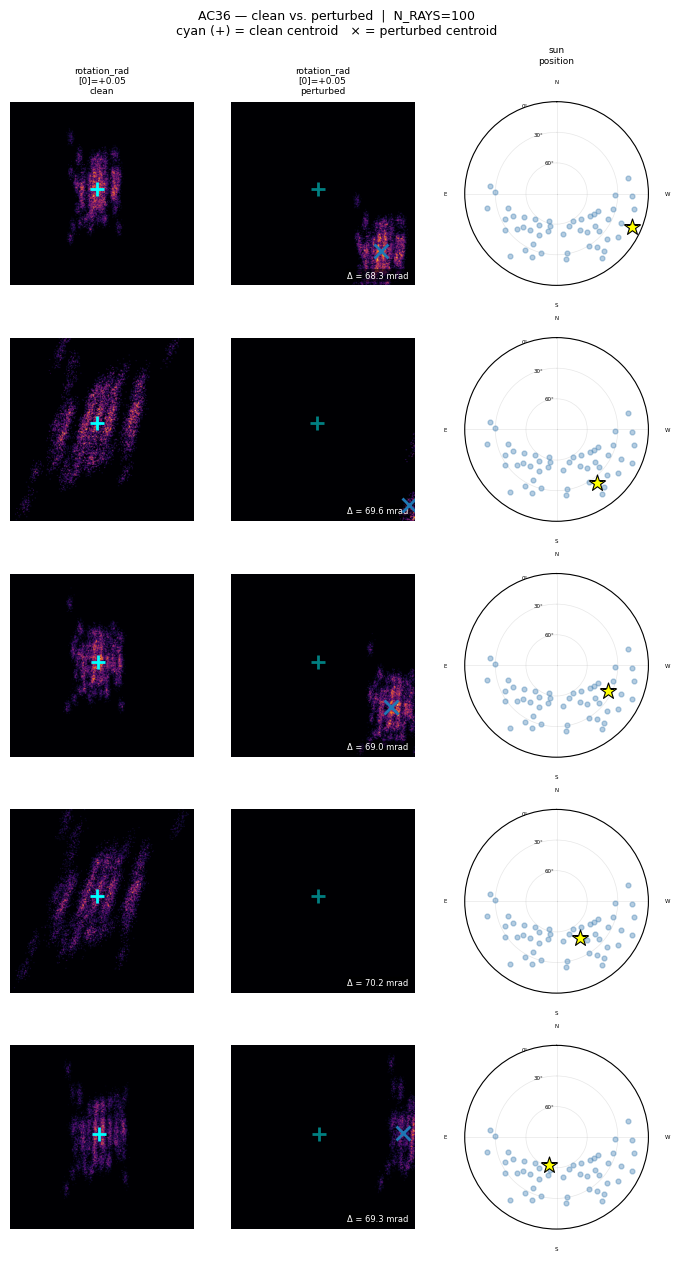

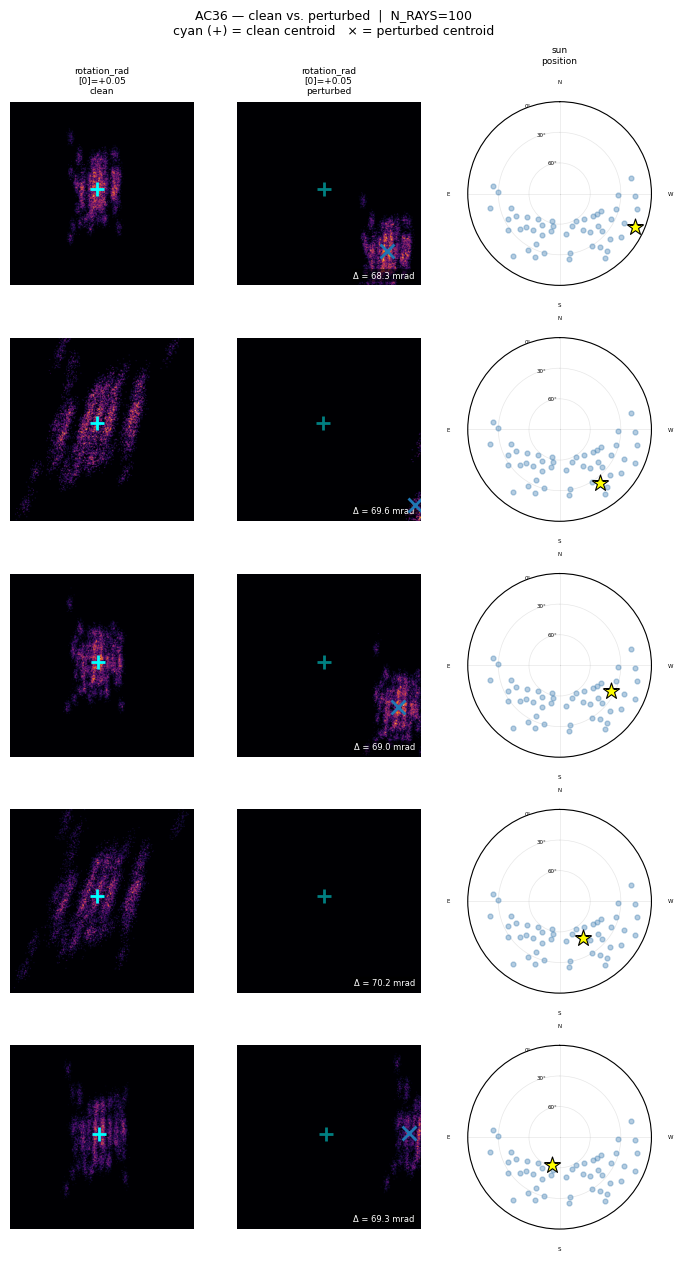

In [6]:
# ── Run with the perturbations defined in CONFIG ─────────────────────────
explore_perturbations(PERTURBATION_DELTAS, n_rays=N_RAYS, n_sun_positions=N_SUN_POSITIONS)


Active groups: ['rotation_rad']
  rotation_rad          : mean=7.9 mrad  max=10.9 mrad


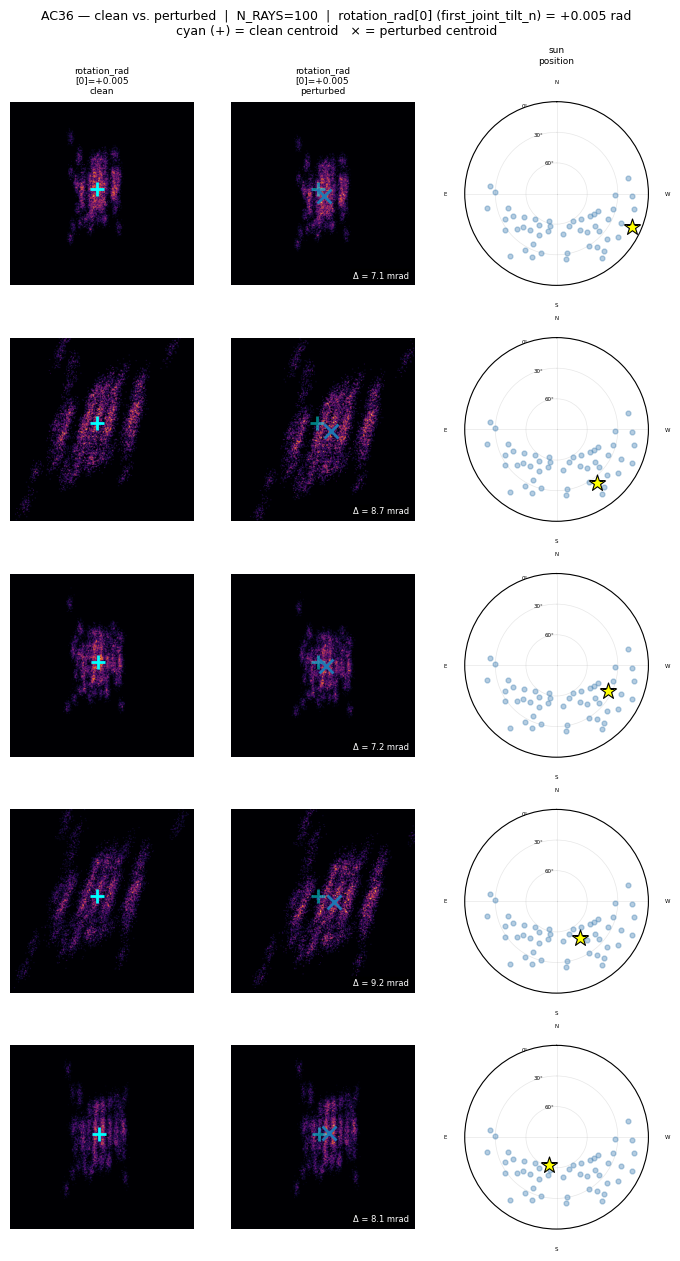

Active groups: ['actuator_angle_rad']
  actuator_angle_rad    : mean=0.0 mrad  max=0.0 mrad


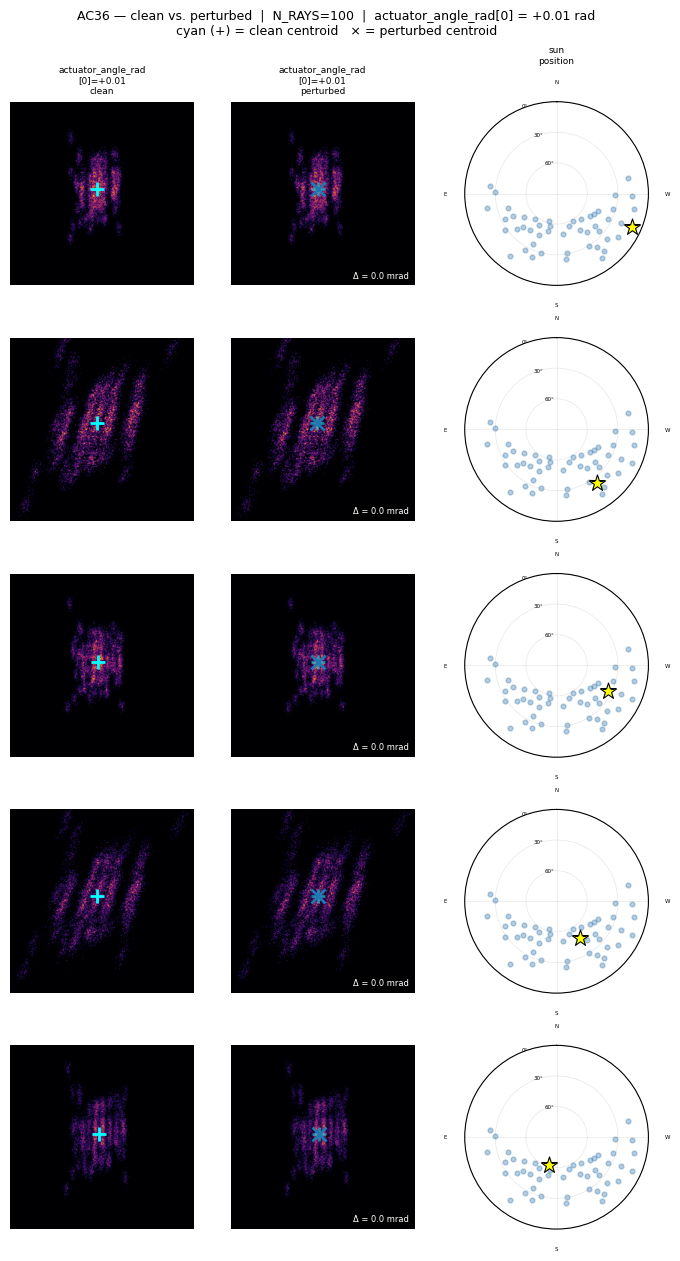

Active groups: ['translation_m']
  translation_m         : mean=0.0 mrad  max=0.0 mrad


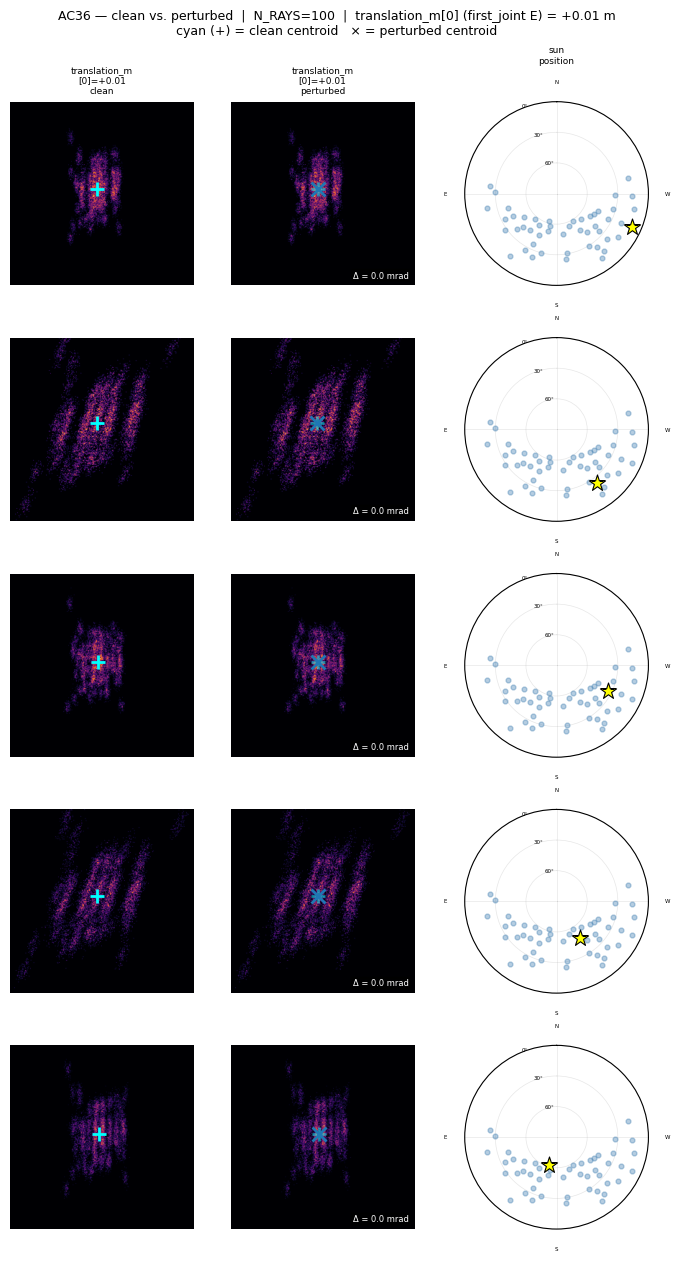

Active groups: ['base_position_m']
  base_position_m       : mean=0.0 mrad  max=0.0 mrad


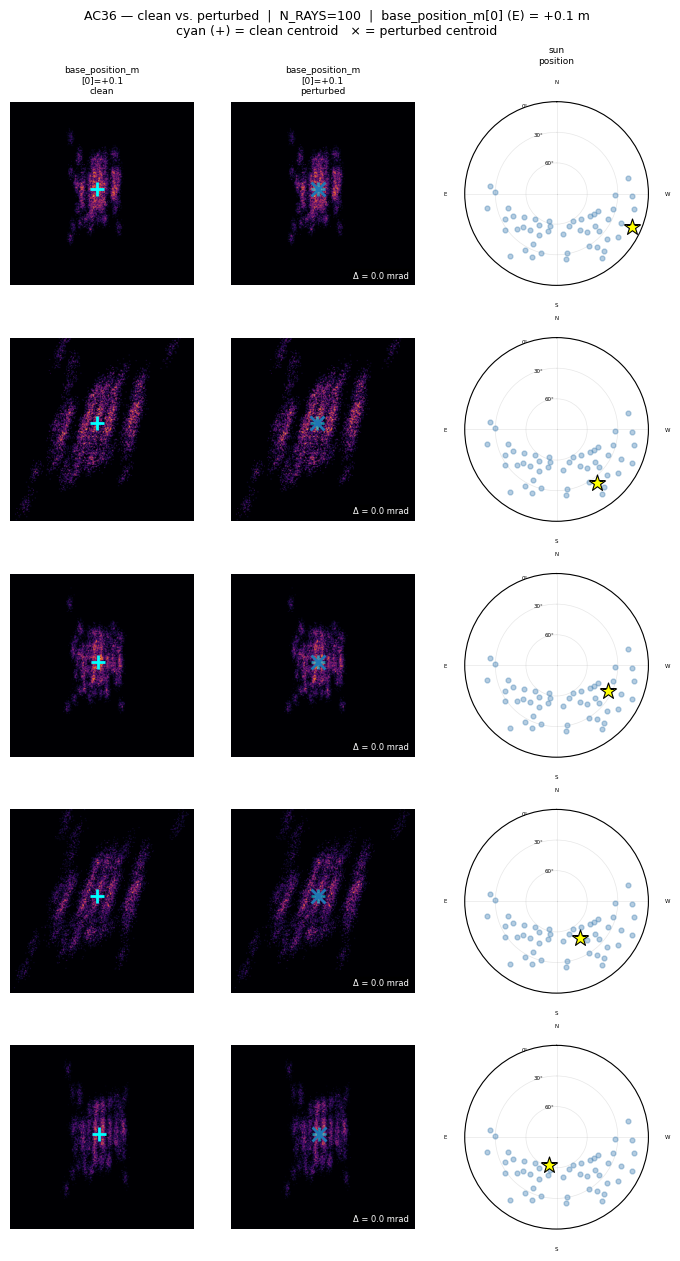

Active groups: ['rotation_rad', 'actuator_angle_rad']
  rotation_rad          : mean=7.9 mrad  max=10.9 mrad
  actuator_angle_rad    : mean=0.0 mrad  max=0.0 mrad
  combined              : mean=7.9 mrad  max=10.8 mrad


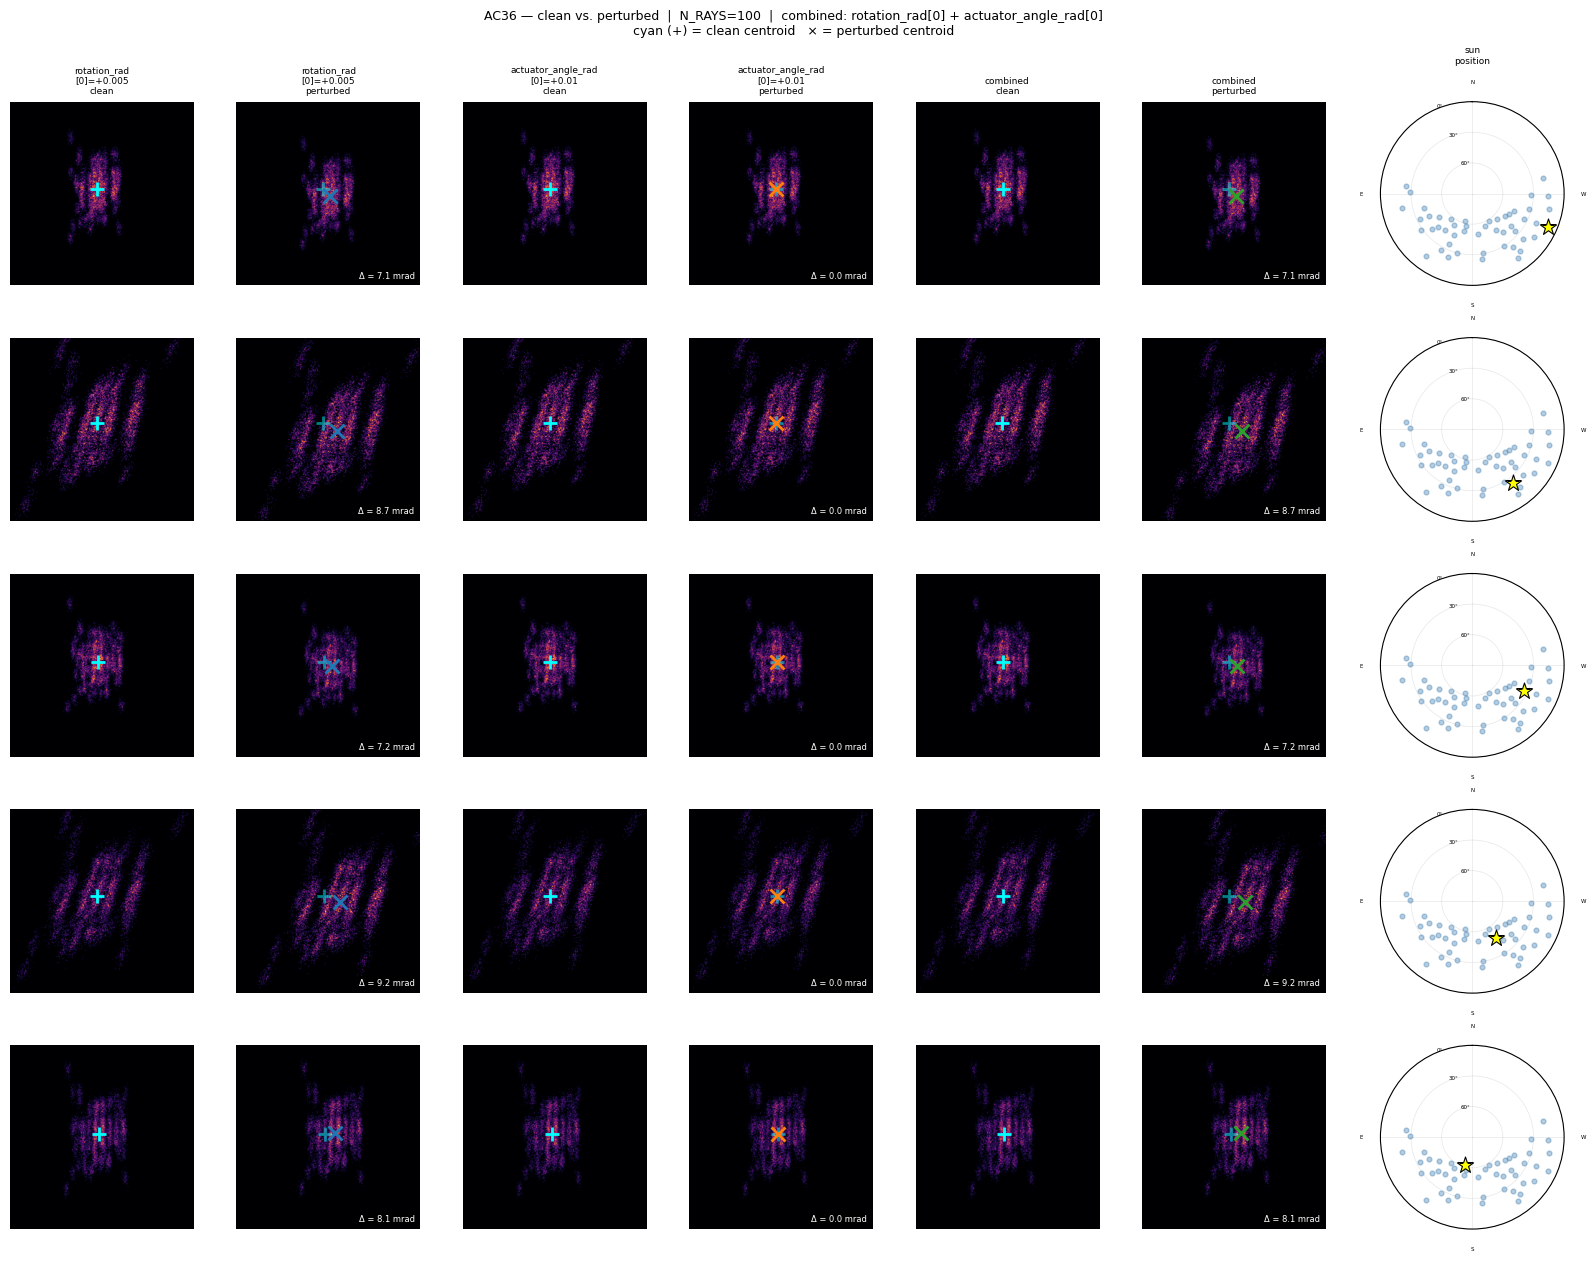

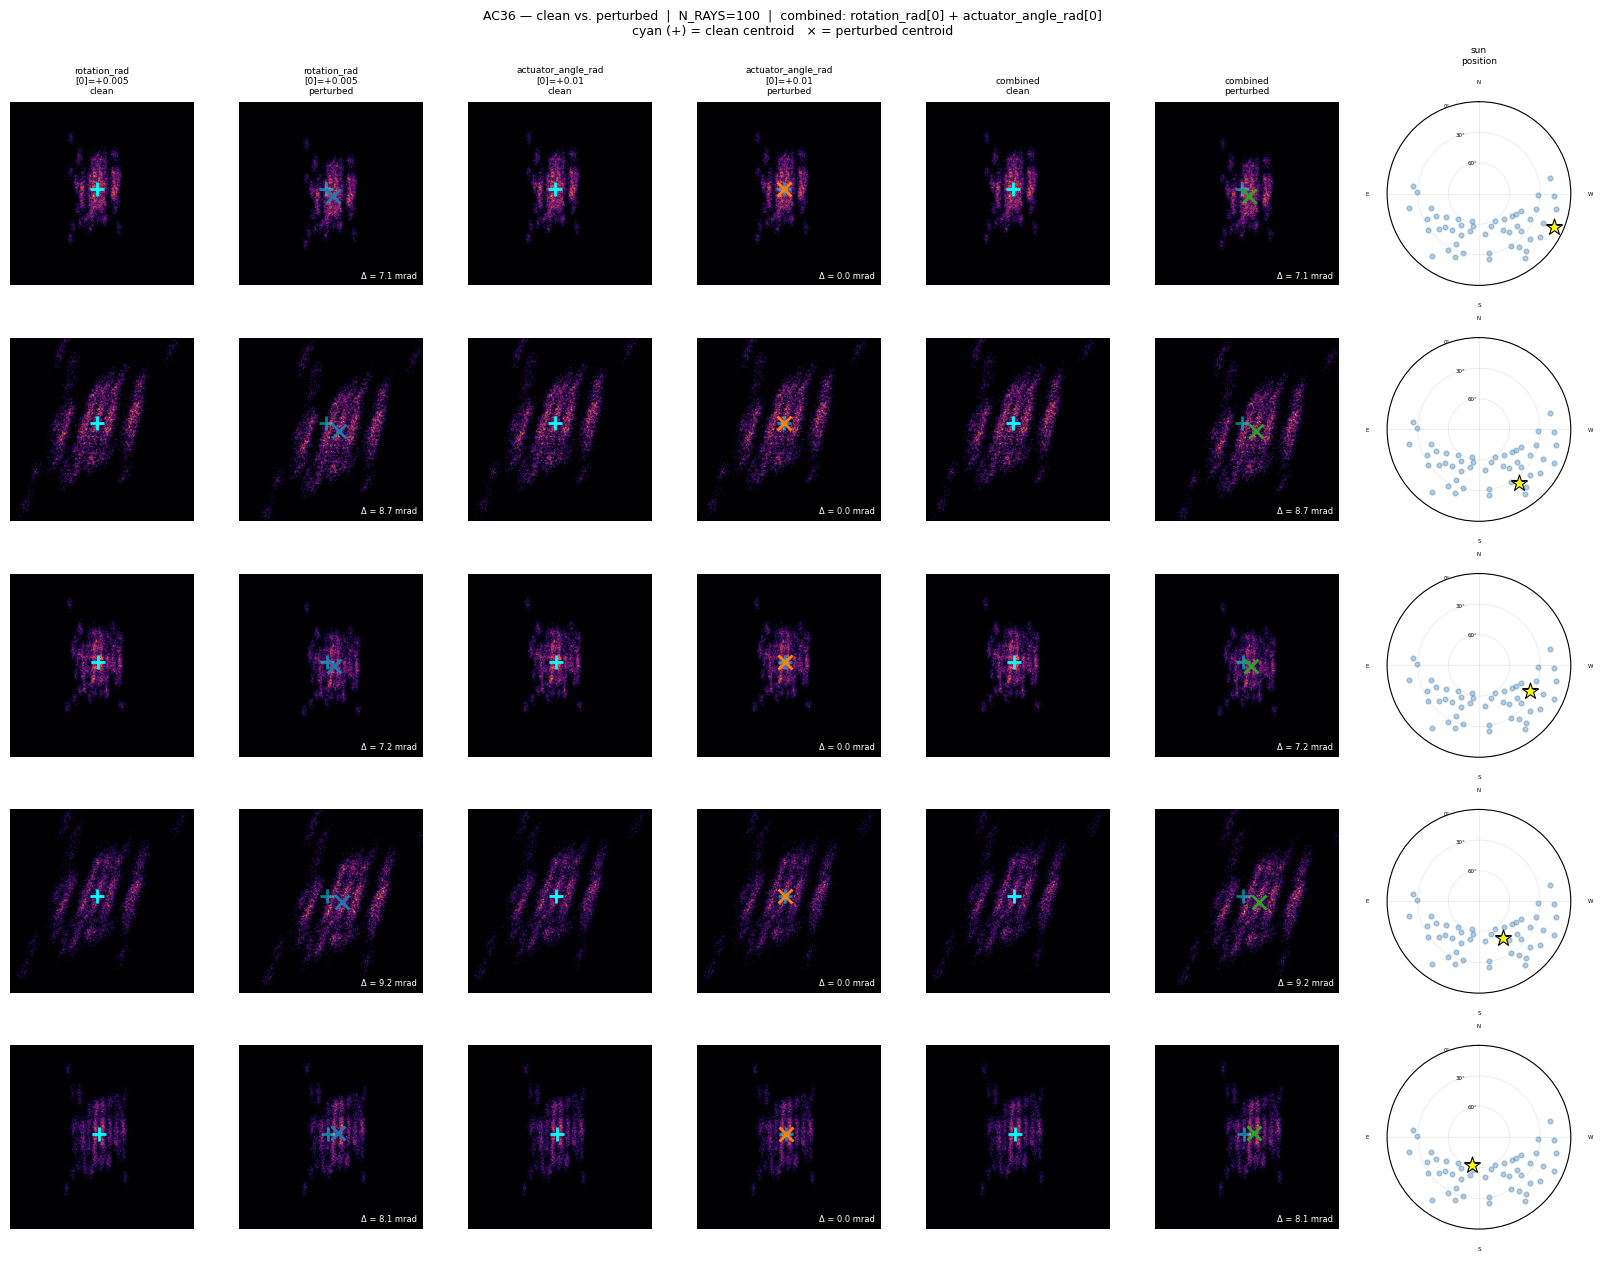

In [7]:
# ── Compare isolated perturbation groups ─────────────────────────────────
# Each call perturbs exactly one group so the effect is isolated.
# Add more keys or combine groups freely.

_ZERO = {
    "rotation_rad":       [0.0, 0.0, 0.0, 0.0],
    "actuator_angle_rad": [0.0, 0.0],
    "actuator_stroke_m":  [0.0, 0.0],
    "actuator_offset_m":  [0.0, 0.0],
    "translation_m":      [0.0] * 9,
    "base_position_m":    [0.0, 0.0, 0.0],
}

# 1. First-joint tilt-N rotation
explore_perturbations(
    {**_ZERO, "rotation_rad": [0.005, 0.0, 0.0, 0.0]},
    n_rays=N_RAYS, n_sun_positions=N_SUN_POSITIONS,
    title="rotation_rad[0] (first_joint_tilt_n) = +0.005 rad",
)

# 2. First actuator initial angle
explore_perturbations(
    {**_ZERO, "actuator_angle_rad": [0.01, 0.0]},
    n_rays=N_RAYS, n_sun_positions=N_SUN_POSITIONS,
    title="actuator_angle_rad[0] = +0.01 rad",
)

# 3. First-joint East translation
explore_perturbations(
    {**_ZERO, "translation_m": [0.01] + [0.0] * 8},
    n_rays=N_RAYS, n_sun_positions=N_SUN_POSITIONS,
    title="translation_m[0] (first_joint E) = +0.01 m",
)

# 4. Base-position East offset
explore_perturbations(
    {**_ZERO, "base_position_m": [0.1, 0.0, 0.0]},
    n_rays=N_RAYS, n_sun_positions=N_SUN_POSITIONS,
    title="base_position_m[0] (E) = +0.1 m",
)

# 5. Combined: rotation + actuator_angle  → shows extra "combined" column
explore_perturbations(
    {**_ZERO, "rotation_rad": [0.005, 0.0, 0.0, 0.0], "actuator_angle_rad": [0.01, 0.0]},
    n_rays=N_RAYS, n_sun_positions=N_SUN_POSITIONS,
    title="combined: rotation_rad[0] + actuator_angle_rad[0]",
)
